In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import fitsio
import ultraplot as uplt

## Look at DB

In [ ]:
import os
import sqlite3

dbname = os.path.expandvars(
    os.path.join(
        "${RUBIN_SIM_DATA_DIR}",
        'matts_extra_sims',
        'test_sim_363.db',
    )
)

conn = sqlite3.connect(dbname)

cursor = conn.cursor()

In [ ]:
# code snippet from AI to get table schmea and names

cursor.execute("SELECT name, sql FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

for table_name, create_sql in tables:
    print(f"--- Schema for Table: {table_name} ---")
    print(create_sql)
    print("\n" + "="*40 + "\n")


In [ ]:
from astropy.time import Time

cursor.execute("select min(observationStartMJD) from observations;")
val = cursor.fetchall()

print(
    Time(val[0][0], format='mjd', scale='tai').utc.datetime,
    Time(val[0][0], format='mjd', scale='utc').utc.datetime,
    Time(val[0][0], format='mjd', scale='tai').datetime,
    Time(val[0][0], format='mjd', scale='utc').datetime,
)

In [ ]:
t = Time(val[0][0], format='mjd', scale='tai')

In [ ]:
t.utc.datetime, t.datetime

## Look at Raw Sims

In [59]:
data = fitsio.read("test_sim_363_ebvlim200_bandsi_nside128_bins8.fits")

In [60]:
from rolling_plot_utils import get_cmap_plus_white, plot_rizexptime_fancy
from rubin_scheduler.scheduler.utils.sky_area import SkyAreaGenerator

nside = 128

sm = SkyAreaGenerator(nside=nside)
footprints_hp_array, labels = sm.return_maps()
wfd_msk = (labels == 'lowdust') | (labels == 'virgo')

{'vmin': np.float64(30.0), 'vmax': np.float64(300.0)}
{'vmin': np.float64(30.0), 'vmax': np.float64(360.0)}
{'vmin': np.float64(30.0), 'vmax': np.float64(480.0)}
{'vmin': np.float64(30.0), 'vmax': np.float64(600.0)}
{'vmin': np.float64(30.0), 'vmax': np.float64(750.0)}
{'vmin': np.float64(90.0), 'vmax': np.float64(930.0)}
{'vmin': np.float64(180.0), 'vmax': np.float64(990.0)}
{'vmin': np.float64(240.0), 'vmax': np.float64(1050.0)}


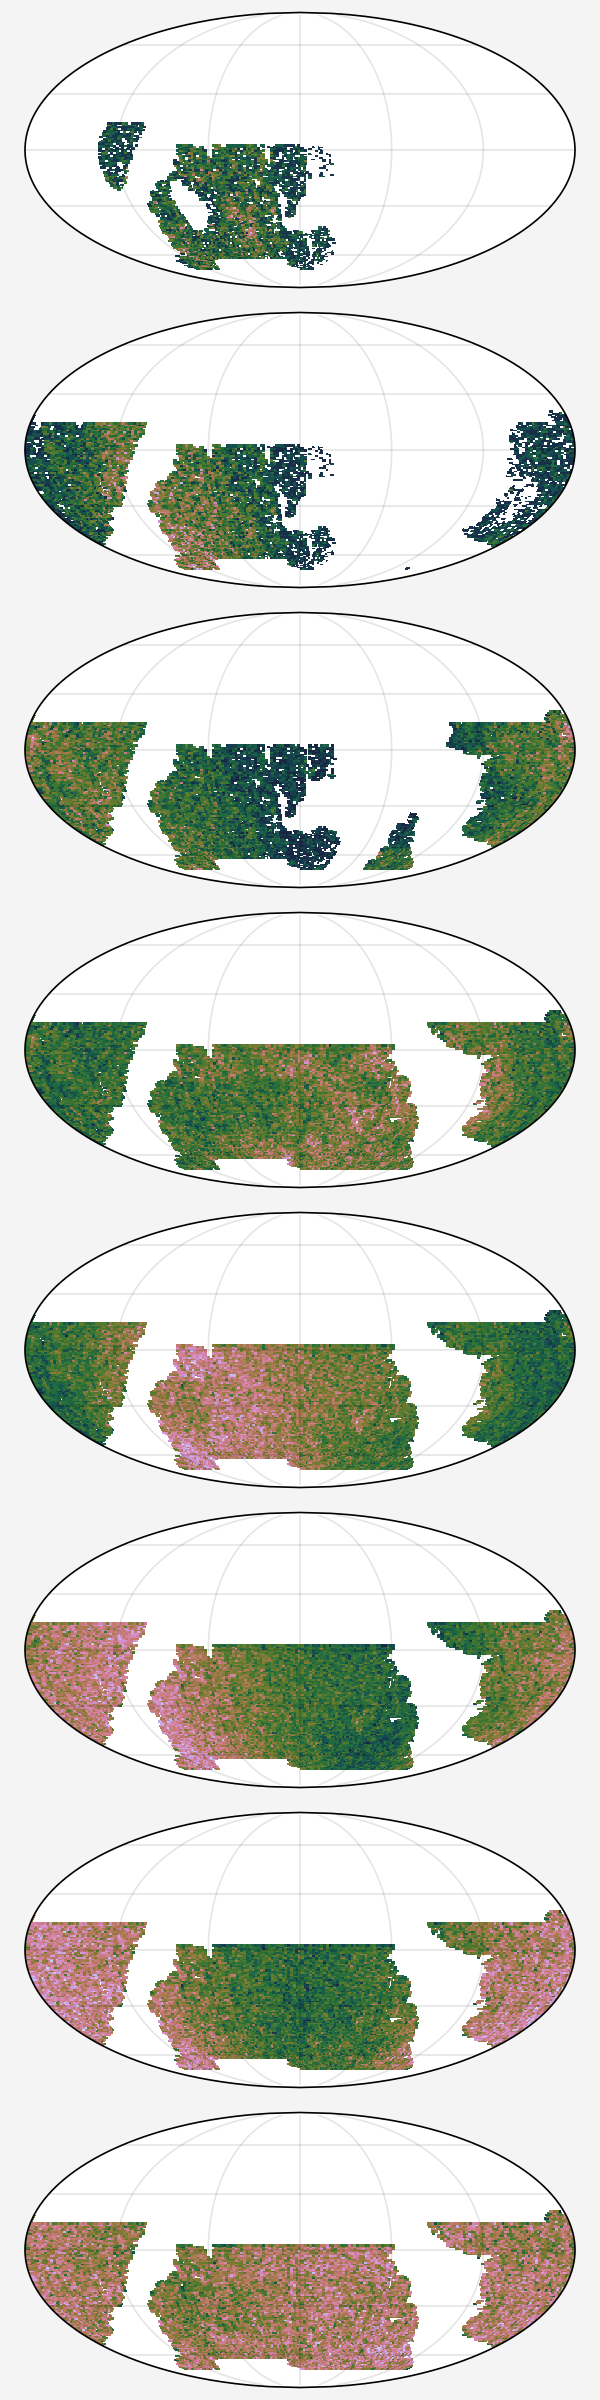

In [61]:
nplot = 8

fig, axs = uplt.subplots(nrows=nplot, ncols=1, figsize=(3, 60 / 40 * nplot), proj="moll", share=0)

mind = -1
for ax in axs[:nplot, 0]:
    mind += 1

    hmap = data[mind, :].copy()
    msk = (~wfd_msk) | (hmap < 15)
    hmap[msk] = np.nan
    print({
        "vmin": np.nanmin(hmap),
        "vmax": np.nanmax(hmap),
    })

    plot_rizexptime_fancy(
        ax,
        hmap,
        1.0,
        npix=200,
        vmin=np.nanmin(hmap),
        vmax=np.nanmax(hmap),
        cmap=get_cmap_plus_white(cmap="cubehelix"),
    )


## Look at a Year

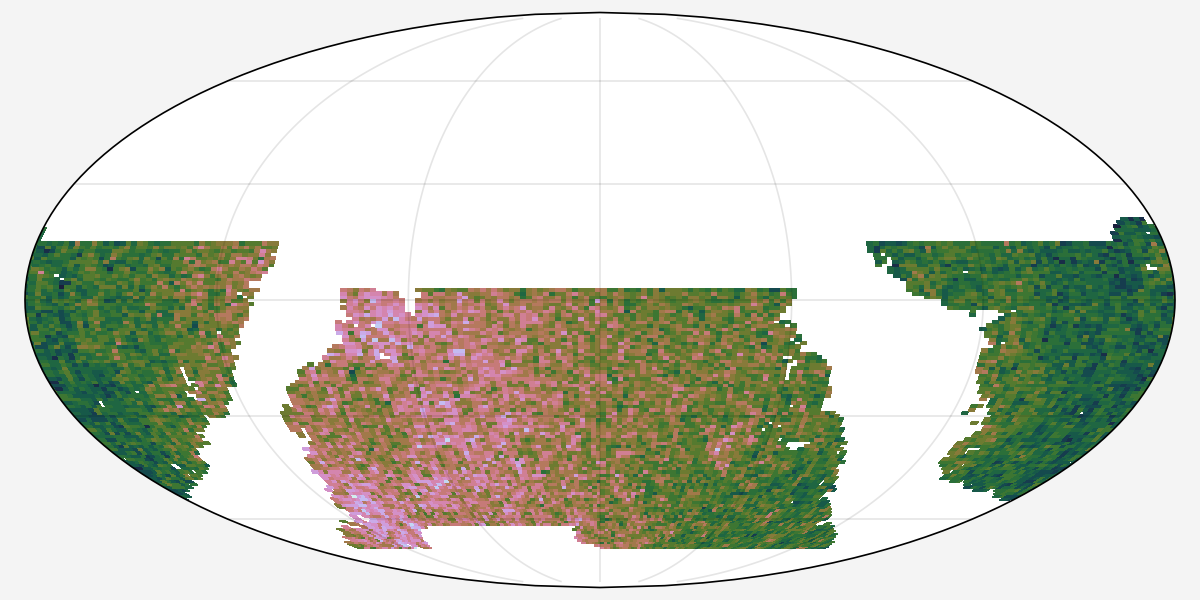

In [68]:
mind = 4  # each year is 4 parts so a year is index 3 or entry 4

hmap = data[mind, :].copy()
msk = (~wfd_msk) | (hmap < 30)
hmap[msk] = np.nan

fig, axs = uplt.subplots(figsize=(6, 3), proj="moll")

plot_rizexptime_fancy(
    axs,
    hmap,
    1.0,
    npix=200,
    vmin=np.nanmin(hmap),
    vmax=np.nanmax(hmap),
    cmap=get_cmap_plus_white(cmap="cubehelix"),
)


In [90]:
import scipy.stats


def compute_extra_var_via_cdf(input_var, target_mean, target_sd):
    cdf = scipy.stats.estimated_cdf(input_var, input_var, nan_policy="omit")
    assert np.all(np.isfinite(cdf) == np.isfinite(input_var))
    msk = np.isfinite(cdf)
    target_var = input_var.copy()
    target_var[msk] = scipy.stats.truncnorm.ppf(cdf[msk], -3, 3, loc=target_mean, scale=target_sd)
    assert np.all(np.isfinite(target_var) == np.isfinite(input_var))
    extra_var = target_var - input_var
    msk = np.isfinite(target_var) & (extra_var < 0)
    extra_var[msk] = 0.0

    msk = np.isfinite(extra_var)
    if np.any(extra_var[msk] < 0):
        print(f"negative variance for mn|sd: {target_mean:0.2e}|{target_sd:0.2e}", flush=True)

    return extra_var


def compute_extra_var_via_time_dif(input_time, target_mean_time, nbins=20, nstd_from_min=3, nstd=3, random_state=None):
    if random_state is None or isinstance(random_state, int):
        rng = np.random.default_rng(random_state)

    target_std_time = (target_mean_time - np.nanmin(input_time)) / nstd_from_min

    new_time = input_time.copy()

    # handle anything in excess of PDF on high side
    bins = np.linspace(np.nanmin(input_time), np.nanmax(input_time) + 1.0, nbins + 1)
    bcen = (bins[1:] + bins[:-1]) / 2.0
    bw = bins[1] - bins[0]

    bvals = scipy.stats.truncnorm.pdf(
        bcen, -nstd, nstd,
        loc=target_mean_time, scale=target_std_time,
    ) * bw * np.sum(np.isfinite(input_time))
    h, _ = np.histogram(input_time[np.isfinite(input_time)], bins=bins)

    msk = (bcen > target_mean_time) & (h >= bvals)
    binds = np.where(msk)[0]
    for bind in binds:
        if h[bind] <= 0:
            continue

        nstd_high = min(nstd, (bins[bind] - target_mean_time) / target_std_time)
        msk = np.isfinite(input_time) & (input_time >= bins[bind]) & (input_time < bins[bind + 1])
        frac = 1.0 - float(bvals[bind]) / float(h[bind])
        nrinds = int(frac * np.sum(msk))
        if nrinds > 0:
            rinds = rng.choice(np.where(msk)[0], size=int(frac * np.sum(msk)), replace=False)
            rinds_times = scipy.stats.truncnorm.rvs(
                -nstd, nstd_high, loc=target_mean_time, scale=target_std_time, random_state=random_state,
                size=rinds.shape[0],
            )
            assert np.all(rinds_times <= new_time[rinds]), (rinds_times, new_time[rinds])
            new_time[rinds] = rinds_times

    # handle anything above 3 sigma
    # msk = np.isfinite(input_time) & (input_time > ulim)
    # if np.any(msk):
    #     msk_times = scipy.stats.truncnorm.rvs(
    #         -nstd, nstd, loc=target_mean_time, scale=target_std_time, random_state=random_state,
    #         size=np.sum(msk)
    #     )
    #     new_time[msk] = msk_times

    return new_time

    # bins = np.linspace(np.nanmin(input_time), np.nanmax(input_time), nbins + 1)
    # bcen = (bins[1:] + bins[:-1]) / 2.0
    # bw = bins[1] - bins[0]

    # bvals = scipy.stats.truncnorm.pdf(
    #     bcen, -3, 3,
    #     loc=target_mean_time, scale=target_std_time,
    # ) * bw * np.sum(np.isfinite(input_time))

    # h, _ = np.histogram(input_time[np.isfinite(input_time)], bins=bins)

    # msk = (bcen > ulim) & (h >= bvals)


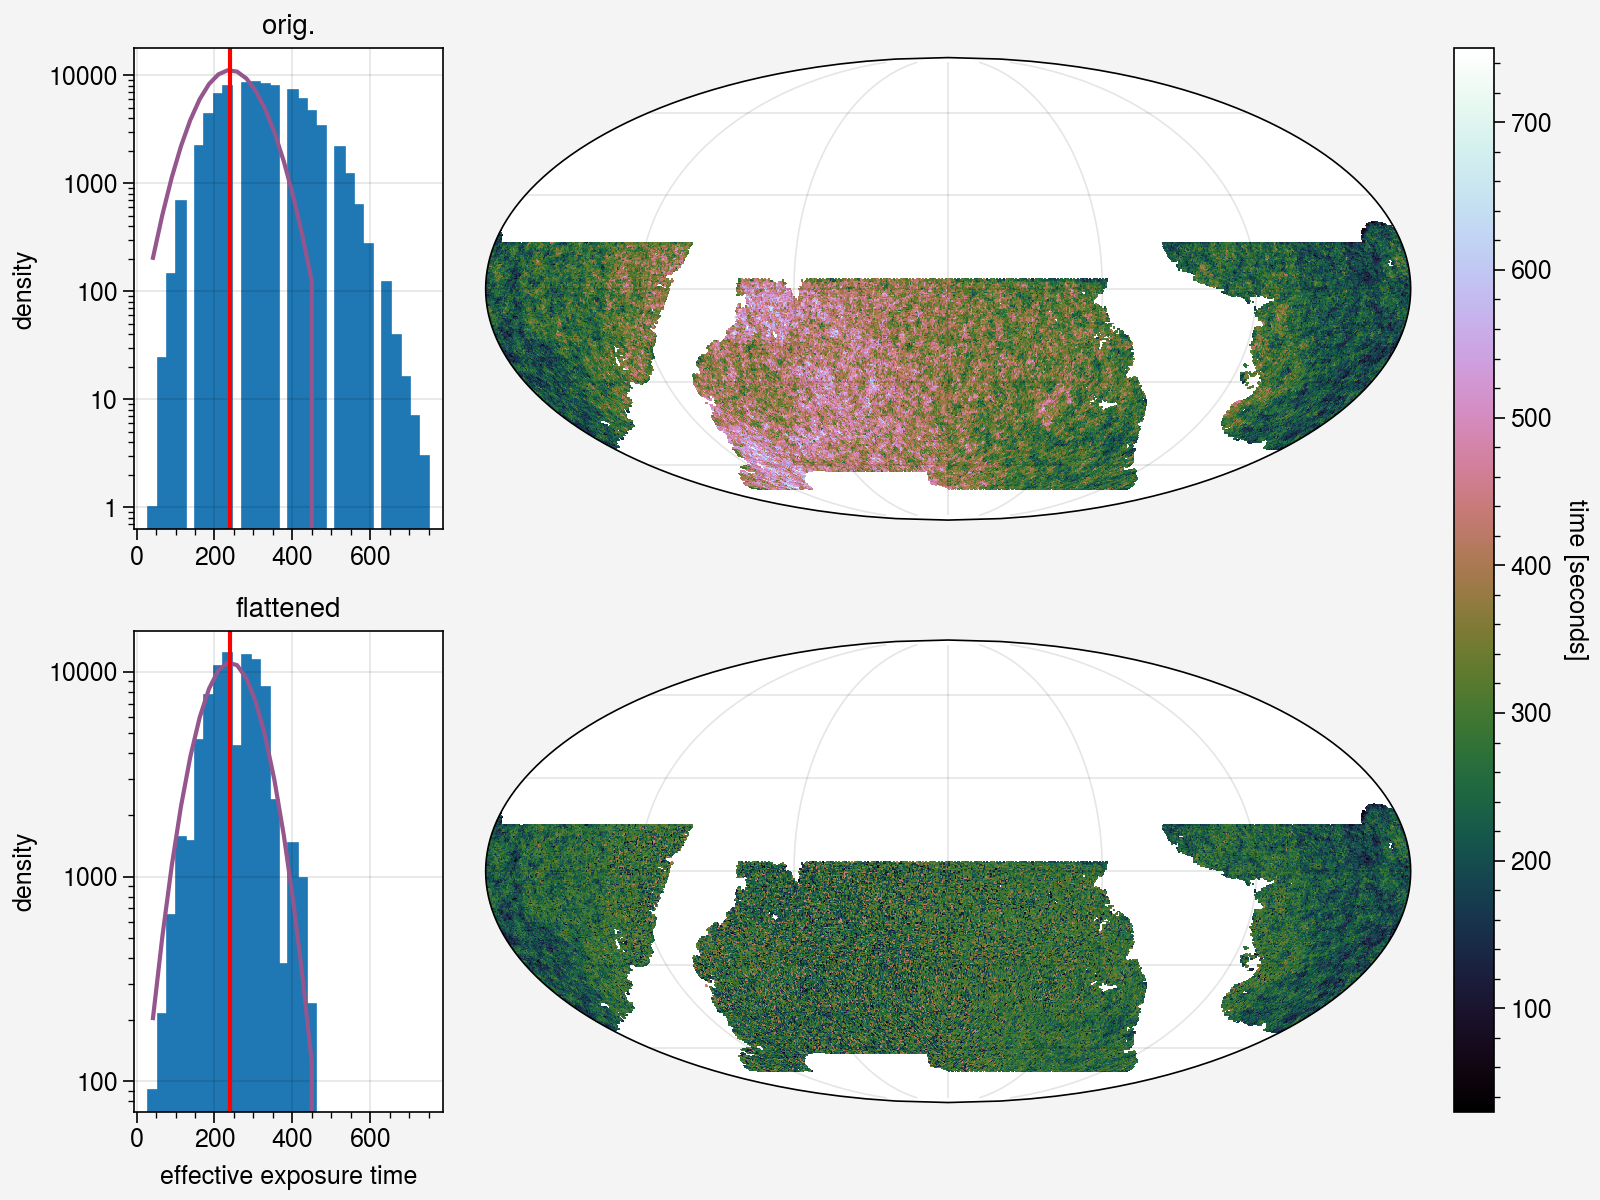

In [92]:
nstd_from_min = 3
nstd = 3

target_mean_time = np.nanmedian(hmap) - 90
new_time = compute_extra_var_via_time_dif(
    hmap, target_mean_time, nstd_from_min=nstd_from_min, nstd=nstd, random_state=None
)
target_std_time = (target_mean_time - np.nanmin(hmap)) / nstd_from_min

bins = np.linspace(np.nanmin(hmap), np.nanmax(hmap), 31)
bcen = (bins[1:] + bins[:-1]) / 2.0
bw = bins[1] - bins[0]
bvals = scipy.stats.truncnorm.pdf(
    bcen, -nstd, nstd, loc=target_mean_time, scale=target_std_time) * bw * np.sum(np.isfinite(hmap))

fig, axs = uplt.subplots(
    nrows=2, ncols=2,
    figsize=(8, 6),
    width_ratios=(2, 6),
    sharex=False, sharey=False,
    proj={(2, 4): "moll"}
)

msk = np.isfinite(hmap)
axs[0, 0].hist(hmap[msk], bins=bins, log=True)
axs[0, 0].plot(bcen, bvals, color="purple")
axs[0, 0].format(title="orig.", ylabel="density")
axs[0, 0].axvline(target_mean_time, color="red")


bvals = scipy.stats.truncnorm.pdf(
    bcen, -nstd, nstd, loc=target_mean_time, scale=target_std_time) * bw * np.sum(np.isfinite(new_time))

msk = np.isfinite(new_time)
axs[1, 0].hist(new_time[msk], bins=bins, log=True)
axs[1, 0].plot(bcen, bvals, color="purple")
axs[1, 0].format(title="orig.", ylabel="density")
axs[1, 0].axvline(target_mean_time, color="red")
axs[1, 0].format(xlabel="effective exposure time", ylabel="density", title="flattened")

vmin = min(np.nanmin(hmap), np.nanmin(new_time))
vmax = max(np.nanmax(hmap), np.nanmax(new_time))

cmap = "cubehelix"

c = plot_rizexptime_fancy(
    axs[0, 1],
    hmap,
    1.0,
    npix=800,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
)
axs[0, 0].format(title="orig.")
fig.colorbar(c, loc="right", label="time [seconds]")

plot_rizexptime_fancy(
    axs[1, 1],
    new_time,
    1.0,
    npix=800,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
)
axs[1, 0].format(title="flattened")

In [ ]:


def compute_extra_var_via_time_pdf(input_var, target_mean, target_sd):
    cdf = scipy.stats.estimated_cdf(input_var, input_var, nan_policy="omit")
    assert np.all(np.isfinite(cdf) == np.isfinite(input_var))
    msk = np.isfinite(cdf)
    target_var = input_var.copy()
    target_var[msk] = scipy.stats.truncnorm.ppf(cdf[msk], -3, 3, loc=target_mean, scale=target_sd)
    assert np.all(np.isfinite(target_var) == np.isfinite(input_var))
    extra_var = target_var - input_var
    msk = np.isfinite(target_var) & (extra_var < 0)
    extra_var[msk] = 0.0

    msk = np.isfinite(extra_var)
    if np.any(extra_var[msk] < 0):
        print(f"negative variance for mn|sd: {target_mean:0.2e}|{target_sd:0.2e}", flush=True)

    return extra_var

In [ ]:
target_mean_time = np.nanmedian(hmap)
target_std_time = (np.nanmedian(hmap) - np.nanmin(hmap)) / 3.0

input_var = 1.0 / hmap

target_mean = 1.0 / target_mean_time
target_std = target_std_time / target_mean_time**2
print(target_mean, target_std)
extra_var = compute_extra_var(input_var, target_mean, target_std)
total_var = input_var + extra_var
total_time = 1.0 / total_var

assert np.all(np.isfinite(total_time) == np.isfinite(hmap))

vmin = min(np.nanmin(hmap), np.nanmin(total_time))
vmax = max(np.nanmax(hmap), np.nanmax(total_time))

print(vmin, vmax)

print(np.nanmedian(hmap), np.nanmedian(total_time))
print(np.nanstd(hmap), np.nanstd(total_time))

0.004166666666666667 0.0026041666666666665
83.47826086956522 660.0
240.0 198.95106556743232
64.69935067509267 83.99551166629048


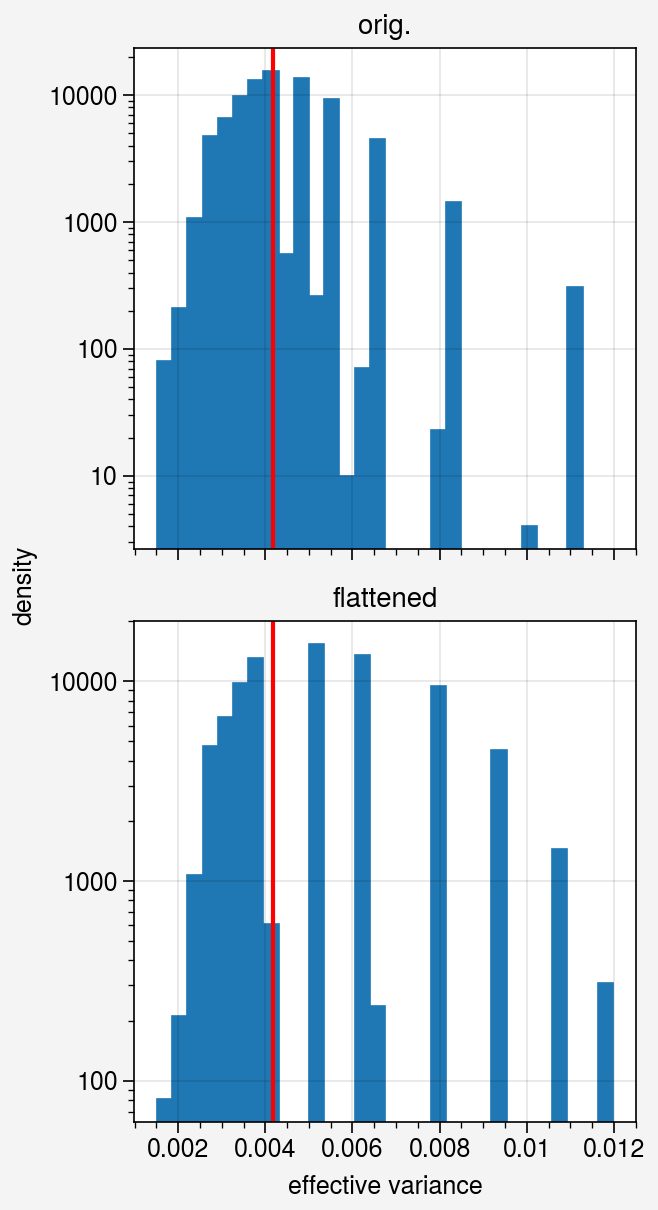

In [162]:
fig, axs = uplt.subplots(nrows=2, ncols=1, sharex=True, sharey=True)

bins = np.linspace(1.0 / vmax, 1.0 / vmin, 31)

msk = np.isfinite(hmap)
axs[0, 0].hist(1.0 / hmap[msk], bins=bins, log=True)
axs[0, 0].format(title="orig.", ylabel="density")
axs[0, 0].axvline(target_mean, color="red")

msk = np.isfinite(total_time)
axs[1, 0].hist(1.0 / total_time[msk], bins=bins, log=True)
axs[1, 0].axvline(target_mean, color="red")

axs[1, 0].format(xlabel="effective variance", ylabel="density", title="flattened")

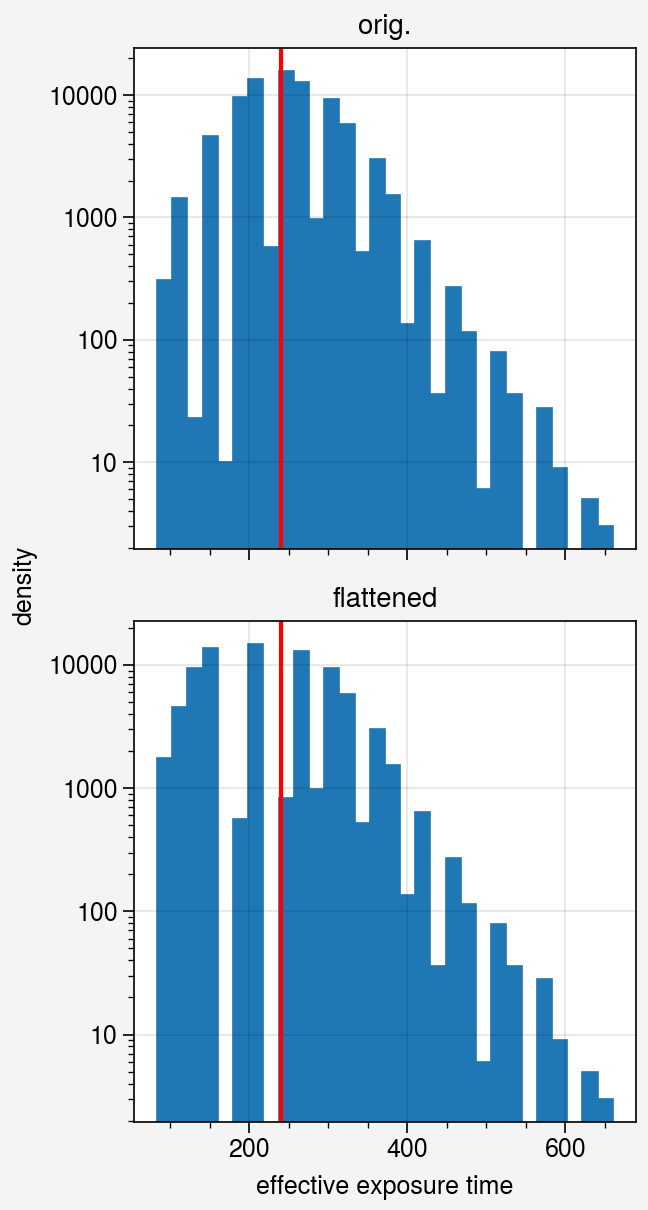

In [163]:
fig, axs = uplt.subplots(nrows=2, ncols=1, sharex=True, sharey=True)

bins = np.linspace(vmin, vmax, 31)

msk = np.isfinite(hmap)
axs[0, 0].hist(hmap[msk], bins=bins, log=True)
axs[0, 0].format(title="orig.", ylabel="density")
axs[0, 0].axvline(target_mean_time, color="red")

msk = np.isfinite(total_time)
axs[1, 0].hist(total_time[msk], bins=bins, log=True)
axs[1, 0].axvline(target_mean_time, color="red")

axs[1, 0].format(xlabel="effective exposure time", ylabel="density", title="flattened")

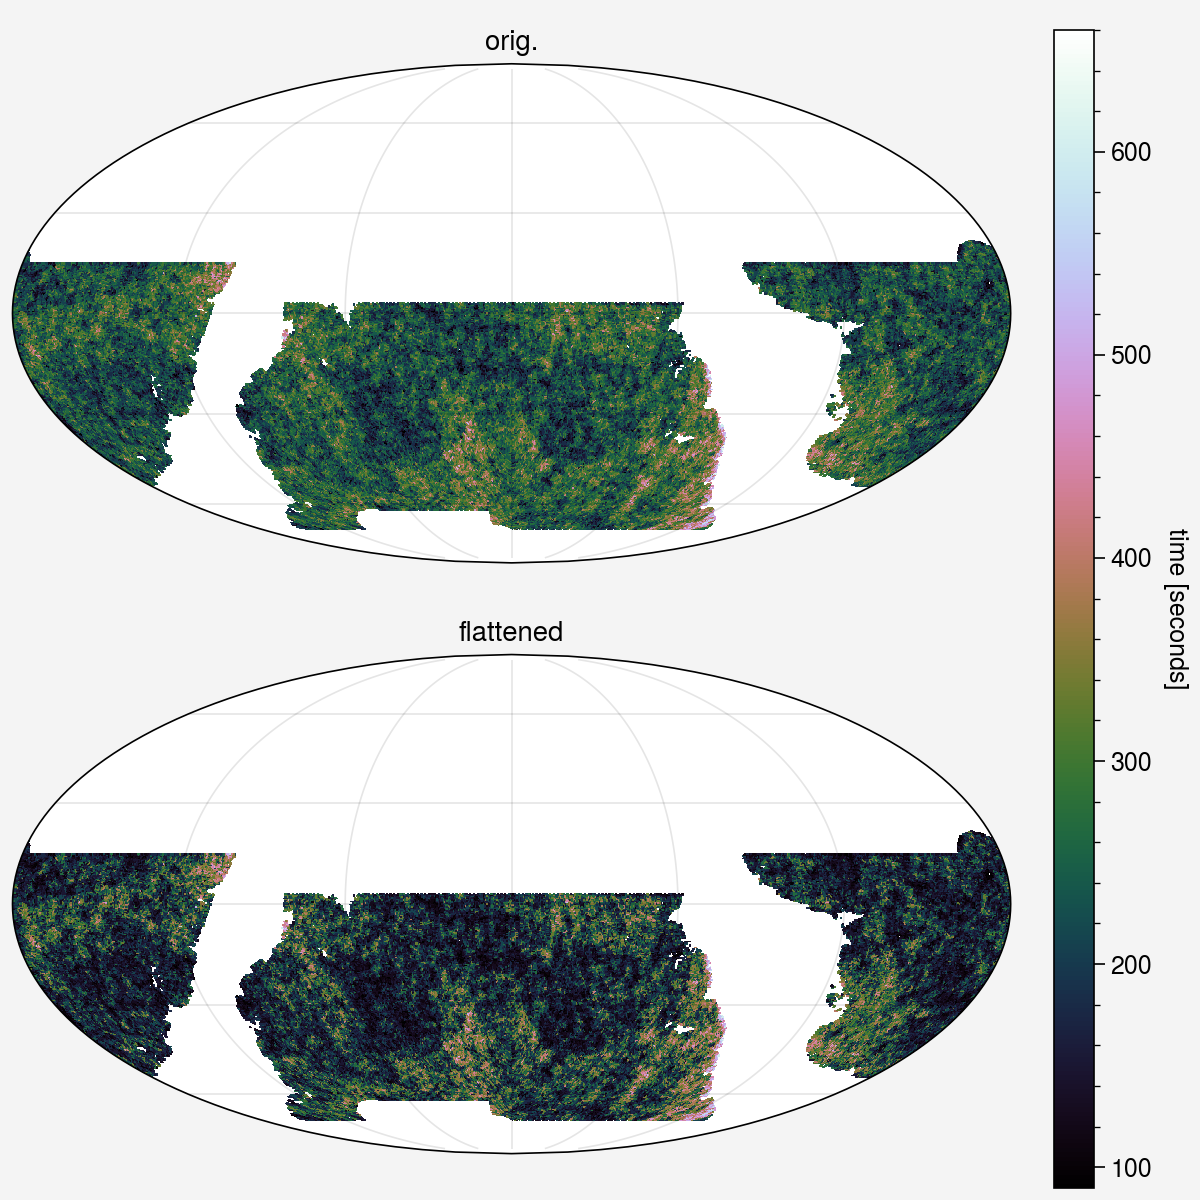

In [160]:
fig, axs = uplt.subplots(nrows=2, ncols=1, figsize=(6, 6), proj="moll")

# cmap = get_cmap_plus_white(cmap="cubehelix")
cmap = "cubehelix"

c = plot_rizexptime_fancy(
    axs[0, 0],
    hmap,
    1.0,
    npix=800,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
)
axs[0, 0].format(title="orig.")
fig.colorbar(c, loc="right", label="time [seconds]")

plot_rizexptime_fancy(
    axs[1, 0],
    total_time,
    1.0,
    npix=800,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
)
axs[1, 0].format(title="flattened")